# Notebook final — Modélisation pré-voyage et post-voyage

Ce notebook reprend les étapes stabilisées du projet IA de planification de séjours :

1. chargement du dataset ;
2. contrôles de cohérence métier ;
3. nettoyage et préparation des données ;
4. feature engineering ;
5. modèle pré-voyage ;
6. modèle post-voyage ;
7. comparaison, choix du modèle et préparation de l'étape suivante.

Les notebooks d'expérimentation restent conservés séparément. Ce notebook sert de version propre pour la suite du projet.

## 1. Cadre métier et règles de fuite de données

Deux objectifs sont distingués :

| Objectif | Moment d'utilisation | Variables autorisées | Variables exclues |
| --- | --- | --- | --- |
| Pré-voyage | Avant le départ | profil, budget, destination, saison, durée, hébergement, météo prévue, activité | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |
| Post-voyage | Après ou pendant le séjour | variables pré-voyage + événements opérationnels observés | `retour_client` brut et variables NLP dérivées |

La cible métier reste `satisfaction_client`.

Pour le modèle post-voyage final, la satisfaction est regroupée en 3 classes :

- `0` : insatisfait, notes 1 et 2 ;
- `1` : neutre, note 3 ;
- `2` : satisfait, notes 4 et 5.

## 2. Imports et configuration

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

RANDOM_STATE = 42
TARGET_COLUMN = "satisfaction_client"

## 3. Chargement du dataset

In [2]:
data_path = Path("..") / "data" / "Examen_travel_planning_dataset.csv"
if not data_path.exists():
    data_path = Path("data") / "Examen_travel_planning_dataset.csv"

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


## 4. Contrôles de cohérence métier initiaux

In [3]:
controle_initial = pd.DataFrame([
    {
        "controle": "doublons trip_id",
        "nb_lignes": int(df_raw["trip_id"].duplicated().sum()),
        "impact": "risque de double comptage",
    },
    {
        "controle": "satisfaction manquante ou hors échelle 1-5",
        "nb_lignes": int((df_raw[TARGET_COLUMN].isna() | ~df_raw[TARGET_COLUMN].between(1, 5)).sum()),
        "impact": "cible invalide pour l'apprentissage",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": int((df_raw["prix_vol"] > df_raw["budget_total"]).sum()),
        "impact": "incohérence budgétaire métier",
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": int(((df_raw["prix_vol"] > df_raw["budget_total"]) & (df_raw["respect_budget"] == 1)).sum()),
        "impact": "contradiction métier forte",
    },
])

display(controle_initial)

,controle,nb_lignes,impact
0,doublons trip_id,0,risque de double comptage
1,satisfaction manquante ou hors échelle 1-5,30,cible invalide pour l'apprentissage
2,prix_vol > budget_total,52,incohérence budgétaire métier
3,prix_vol > budget_total et respect_budget = 1,5,contradiction métier forte


## 5. Nettoyage des donnees

In [4]:
def nettoyer_dataset(df_source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df_source.copy()
    nb_initial = len(df)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = df[column].astype("string").str.strip().str.lower()

    numeric_source_columns = [
        "budget_total",
        "duree_jours",
        "prix_vol",
        TARGET_COLUMN,
        "reorganisation_necessaire",
        "respect_budget",
    ]

    for column in numeric_source_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df[df[TARGET_COLUMN].between(1, 5)].copy()
    nb_after_target = len(df)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    budget_valid_mask = (
        df["prix_vol"].isna()
        | df["budget_total"].isna()
        | (df["prix_vol"] <= df["budget_total"])
    )
    df = df[budget_valid_mask].copy()
    nb_after_budget = len(df)

    numeric_missing_columns = ["budget_total", "duree_jours", "prix_vol"]
    for column in numeric_missing_columns:
        df[column] = df[column].fillna(df[column].median())

    categorical_mode_columns = [
        "client_type",
        "destination",
        "saison",
        "type_hebergement",
        "meteo_prevue",
        "activite_principale",
    ]

    for column in categorical_mode_columns:
        mode_values = df[column].mode(dropna=True)
        fill_value = mode_values.iloc[0] if not mode_values.empty else "inconnu"
        df[column] = df[column].fillna(fill_value).replace({"nan": fill_value})

    df["imprevus"] = df["imprevus"].fillna("aucun").replace({"nan": "aucun"})
    df["retour_client"] = df["retour_client"].fillna("").replace({"nan": ""})

    for column in ["reorganisation_necessaire", "respect_budget"]:
        mode_value = df[column].mode(dropna=True).iloc[0]
        df[column] = df[column].fillna(mode_value).astype(int)

    outlier_columns = ["budget_total", "duree_jours", "prix_vol"]
    outlier_rows = []

    for column in outlier_columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        median_value = df[column].median()
        outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
        nb_outliers = int(outlier_mask.sum())
        df.loc[outlier_mask, column] = median_value

        outlier_rows.append({
            "colonne": column,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "borne_basse": round(lower_bound, 2),
            "borne_haute": round(upper_bound, 2),
            "mediane_remplacement": round(median_value, 2),
            "outliers_traites": nb_outliers,
        })

    nb_before_final_budget_check = len(df)
    df = df[df["prix_vol"] <= df["budget_total"]].copy()
    nb_after_final_budget_check = len(df)

    cleaning_report = pd.DataFrame([
        {
            "etape": "dataset brut",
            "nb_lignes": nb_initial,
            "lignes_supprimees": 0,
        },
        {
            "etape": "cible satisfaction_client valide",
            "nb_lignes": nb_after_target,
            "lignes_supprimees": nb_initial - nb_after_target,
        },
        {
            "etape": "cohérence initiale prix_vol <= budget_total",
            "nb_lignes": nb_after_budget,
            "lignes_supprimees": nb_after_target - nb_after_budget,
        },
        {
            "etape": "contrôle budget après traitement outliers",
            "nb_lignes": nb_after_final_budget_check,
            "lignes_supprimees": nb_before_final_budget_check - nb_after_final_budget_check,
        },
    ])

    outlier_report = pd.DataFrame(outlier_rows)
    return df, cleaning_report, outlier_report


df_model, cleaning_report, outlier_report = nettoyer_dataset(df_raw)

display(cleaning_report)
display(outlier_report)
print(f"Volume final après nettoyage : {len(df_model)} lignes")
print("Valeurs manquantes restantes :", int(df_model.isna().sum().sum()))

,etape,nb_lignes,lignes_supprimees
0,dataset brut,1500,0
1,cible satisfaction_client valide,1470,30
2,cohérence initiale prix_vol <= budget_total,1418,52
3,contrôle budget après traitement outliers,1414,4


,colonne,Q1,Q3,IQR,borne_basse,borne_haute,mediane_remplacement,outliers_traites
0,budget_total,4319.11,9876.80,5557.69,-4017.43,18213.34,6687.90,17
1,duree_jours,7.00,14.00,7.00,-3.50,24.50,10.00,4
2,prix_vol,952.26,1286.64,334.38,450.69,1788.21,1113.81,24


Volume final après nettoyage : 1414 lignes
Valeurs manquantes restantes : 0


## 6. Feature engineering

In [5]:
def ajouter_features_base(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()

    safe_duree = df["duree_jours"].replace(0, np.nan)
    safe_budget = df["budget_total"].replace(0, np.nan)

    df["budget_par_jour"] = df["budget_total"] / safe_duree
    df["part_vol_budget"] = df["prix_vol"] / safe_budget
    df["budget_hors_vol"] = df["budget_total"] - df["prix_vol"]
    df["sejour_long"] = (df["duree_jours"] >= 14).astype(int)
    df["meteo_risque"] = df["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
    df["randonnee_meteo_risque"] = (
        df["activite_principale"].isin(["randonnée", "randonnee", "randonn?e"])
        & df["meteo_prevue"].isin(["pluie", "variable"])
    ).astype(int)
    df["saison_haute"] = df["saison"].isin(["été", "ete", "?t?", "hiver"]).astype(int)
    df["client_business"] = (df["client_type"] == "business").astype(int)
    df["hebergement_luxe"] = df["type_hebergement"].isin(["resort", "villa"]).astype(int)

    destination_enrichment = pd.DataFrame({
        "destination": ["paris", "rome", "lisbonne", "new york", "dubaï", "tokyo", "bali", "sydney"],
        "region_destination": ["europe", "europe", "europe", "amérique du nord", "moyen-orient", "asie", "asie", "océanie"],
        "type_destination": ["culture", "culture", "culture", "urbain_business", "luxe_shopping", "culture_urbain", "plage_luxe", "urbain_nature"],
        "distance_vol_categorie": ["court", "court", "court", "long", "moyen", "long", "long", "long"],
        "cout_vie_destination": ["élevé", "moyen", "moyen", "élevé", "élevé", "élevé", "moyen", "élevé"],
        "destination_luxe": [1, 1, 0, 1, 1, 1, 1, 1],
        "decalage_horaire_categorie": ["faible", "faible", "faible", "moyen", "moyen", "fort", "fort", "fort"],
        "risque_meteo_destination": ["moyen", "moyen", "faible", "moyen", "faible", "moyen", "élevé", "moyen"],
    })

    df = df.merge(destination_enrichment, on="destination", how="left", validate="many_to_one")

    enriched_columns = [
        "region_destination",
        "distance_vol_categorie",
        "destination_luxe",
    ]

    for column in enriched_columns:
        if df[column].isna().any():
            df[column] = df[column].fillna("inconnu")

    # Variables post-voyage explicatives : utilisées uniquement dans le modèle post-voyage.
    df["imprevu_present"] = (df["imprevus"] != "aucun").astype(int)
    df["imprevu_transport"] = df["imprevus"].isin(["retard_vol", "annulation", "bagages"]).astype(int)
    df["imprevu_meteo"] = df["imprevus"].isin(["météo", "meteo", "m?t?o"]).astype(int)
    df["budget_non_respecte"] = (df["respect_budget"] == 0).astype(int)
    df["gravite_imprevu"] = df["imprevus"].map({
        "aucun": 0,
        "météo": 1,
        "meteo": 1,
        "m?t?o": 1,
        "bagages": 1,
        "retard_vol": 2,
        "annulation": 3,
    }).fillna(1).astype(int)
    df["annulation_et_reorganisation"] = (
        (df["imprevus"] == "annulation")
        & (df["reorganisation_necessaire"] == 1)
    ).astype(int)
    df["retard_et_budget_non_respecte"] = (
        (df["imprevus"] == "retard_vol")
        & (df["budget_non_respecte"] == 1)
    ).astype(int)
    df["imprevu_transport_et_sejour_court"] = (
        (df["imprevu_transport"] == 1)
        & (df["duree_jours"] <= 5)
    ).astype(int)
    df["budget_tendu"] = (df["part_vol_budget"] >= 0.5).astype(int)
    df["budget_tendu_et_hebergement_luxe"] = (
        (df["budget_tendu"] == 1)
        & (df["hebergement_luxe"] == 1)
    ).astype(int)

    for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
        df[column] = df[column].replace([np.inf, -np.inf], np.nan)

    return df


df_model = ajouter_features_base(df_model)

features_supprimees_modelisation = [
    "budget_hors_vol",
    "saison_haute",
    "cout_vie_destination",
    "type_destination",
    "decalage_horaire_categorie",
    "risque_meteo_destination",
    "annulation_et_reorganisation",
    "retard_et_budget_non_respecte",
    "imprevu_transport_et_sejour_court",
    "budget_tendu_et_hebergement_luxe",
]

df_model = df_model.drop(columns=features_supprimees_modelisation, errors="ignore")

features_base = [
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "randonnee_meteo_risque",
    "client_business",
    "hebergement_luxe",
    "destination_luxe",
]

features_post_voyage_explicatives = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
]

print("Dimensions après feature engineering :", df_model.shape)
display(df_model[features_base + [TARGET_COLUMN]].head())

Dimensions après feature engineering : (1414, 31)


,budget_par_jour,part_vol_budget,sejour_long,meteo_risque,randonnee_meteo_risque,client_business,hebergement_luxe,destination_luxe,satisfaction_client
0,1849.633333,0.238024,0,0,0,0,0,1,3
1,274.022500,0.463493,0,1,1,1,0,1,4
2,834.198750,0.066077,1,0,0,0,1,1,5
3,414.671765,0.119781,1,0,0,0,0,1,3
4,1087.560000,0.142027,0,1,0,0,0,1,2


## 7. Fonctions de modelisation

In [6]:
def construire_preprocesseur(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    numeric_features = X.select_dtypes(include="number").columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    return preprocess, numeric_features, categorical_features


def evaluer_classification(modeles: dict, X_train, X_test, y_train, y_test, preprocess) -> tuple[pd.DataFrame, dict]:
    rows = []
    fitted = {}

    for model_name, model in modeles.items():
        pipeline = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", model),
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        rows.append({
            "modele": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        })
        fitted[model_name] = pipeline

    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, fitted


def afficher_distribution(y: pd.Series, label: str) -> None:
    print(label)
    display(
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
        .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
    )

## 8. Modèle pré-voyage

Objectif : prédire la satisfaction avant le départ.

Règle clé : les variables post-voyage sont exclues pour éviter la fuite de données.

In [7]:
post_trip_columns = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "retour_client",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
    "annulation_et_reorganisation",
    "retard_et_budget_non_respecte",
    "imprevu_transport_et_sejour_court",
    "budget_tendu_et_hebergement_luxe",
]

technical_columns = ["trip_id"]
excluded_pre_voyage = [TARGET_COLUMN, *technical_columns, *post_trip_columns]
feature_columns_pre = [
    column for column in df_model.columns
    if column not in excluded_pre_voyage
]

X_pre = df_model[feature_columns_pre].copy()
y_pre = df_model[TARGET_COLUMN].astype(int).copy()

preprocess_pre, numeric_pre, categorical_pre = construire_preprocesseur(X_pre)

resume_pre = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_pre), len(categorical_pre), X_pre.shape[1], len(excluded_pre_voyage)],
    "colonnes": [numeric_pre, categorical_pre, feature_columns_pre, excluded_pre_voyage],
})

display(resume_pre)
afficher_distribution(y_pre, "Distribution cible pré-voyage")

,famille,nombre,colonnes
0,numeriques,11,"[budget_total, duree_jours, prix_vol, budget_p..."
1,categorielles,8,"[client_type, destination, saison, type_heberg..."
2,total,19,"[client_type, budget_total, destination, saiso..."
3,exclues,16,"[satisfaction_client, trip_id, imprevus, reorg..."


Distribution cible pré-voyage


,classe,nombre,pourcentage
0,1,250,17.68
1,2,410,29.00
2,3,341,24.12
3,4,247,17.47
4,5,166,11.74


### 8.1 Corrélations pré-voyage

In [8]:
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre,
)

correlation_df_pre = X_train_pre[numeric_pre].copy()
correlation_df_pre[TARGET_COLUMN] = y_train_pre.values

spearman_pre = (
    correlation_df_pre.corr(method="spearman")[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(spearman_pre.to_frame("correlation_spearman_satisfaction").round(4).head(15))

,correlation_spearman_satisfaction
budget_total,0.0604
budget_par_jour,0.0580
part_vol_budget,-0.0577
destination_luxe,0.0504
hebergement_luxe,0.0378
randonnee_meteo_risque,0.0280
duree_jours,0.0167
meteo_risque,-0.0101
prix_vol,0.0079
client_business,-0.0047


### 8.2 Comparaison des modèles pré-voyage

In [9]:
modeles_pre = {
    "Dummy_majority_pre": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_pre": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_pre": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_pre": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_pre, fitted_pre = evaluer_classification(
    modeles_pre,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

display(results_pre.round(4))
best_pre_model_name = results_pre.iloc[0]["modele"]
print("Meilleur modèle pré-voyage :", best_pre_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,ExtraTrees_pre,0.2438,0.2390,0.2340
1,RandomForest_pre,0.2297,0.2138,0.2135
2,LogisticRegression_pre,0.1873,0.1929,0.1856
3,Dummy_majority_pre,0.2898,0.2000,0.0899


Meilleur modèle pré-voyage : ExtraTrees_pre


### 8.3 Interprétation pré-voyage

Le modèle pré-voyage est méthodologiquement conforme au cas d'usage de planification, car il ne dépend que de variables connues avant le séjour.

Les performances restent toutefois limitées. Cette limite est cohérente avec les analyses précédentes : les caractéristiques disponibles avant départ contiennent peu de signal pour expliquer précisément la satisfaction finale.

## 9. Modèle post-voyage

Objectif : expliquer ou prédire la satisfaction après le séjour à partir des événements opérationnels observés.

Les variables `imprevus`, `reorganisation_necessaire` et `respect_budget` sont incluses.

Le texte libre `retour_client` reste exclu du modèle principal, car il reflète directement le ressenti client et peut créer une fuite très forte.

In [10]:
def satisfaction_to_3_classes(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


excluded_post_voyage = [
    "trip_id",
    TARGET_COLUMN,
    "retour_client",
    *features_supprimees_modelisation,
]

feature_columns_post = [
    column for column in df_model.columns
    if column not in excluded_post_voyage
]

X_post = df_model[feature_columns_post].copy()
y_post = df_model[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

preprocess_post, numeric_post, categorical_post = construire_preprocesseur(X_post)

resume_post = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_post), len(categorical_post), X_post.shape[1], len(excluded_post_voyage)],
    "colonnes": [numeric_post, categorical_post, feature_columns_post, excluded_post_voyage],
})

display(resume_post)
afficher_distribution(y_post, "Distribution cible post-voyage 3 classes")
print("Variables post-voyage explicatives incluses :")
print([column for column in features_post_voyage_explicatives if column in X_post.columns])

,famille,nombre,colonnes
0,numeriques,19,"[budget_total, duree_jours, prix_vol, reorgani..."
1,categorielles,9,"[client_type, destination, saison, type_heberg..."
2,total,28,"[client_type, budget_total, destination, saiso..."
3,exclues,13,"[trip_id, satisfaction_client, retour_client, ..."


Distribution cible post-voyage 3 classes


,classe,nombre,pourcentage
0,0,660,46.68
1,1,341,24.12
2,2,413,29.21


Variables post-voyage explicatives incluses :
['imprevus', 'reorganisation_necessaire', 'respect_budget', 'imprevu_present', 'imprevu_transport', 'imprevu_meteo', 'budget_non_respecte', 'budget_tendu', 'gravite_imprevu']


### 9.1 Comparaison des modèles post-voyage 3 classes

In [11]:
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(
    X_post,
    y_post,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_post,
)

modeles_post = {
    "Dummy_majority_3_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_3_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_3_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_3_classes": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_post, fitted_post = evaluer_classification(
    modeles_post,
    X_train_post,
    X_test_post,
    y_train_post,
    y_test_post,
    preprocess_post,
)

display(results_post.round(4))
best_post_model_name = results_post.iloc[0]["modele"]
print("Meilleur modèle post-voyage initial :", best_post_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,ExtraTrees_3_classes,0.4346,0.3955,0.3939
1,RandomForest_3_classes,0.4700,0.4062,0.3921
2,LogisticRegression_3_classes,0.3816,0.3695,0.3669
3,Dummy_majority_3_classes,0.4664,0.3333,0.2120


Meilleur modèle post-voyage initial : ExtraTrees_3_classes


### 9.2 Tests complémentaires non retenus

In [12]:
tests_complementaires = []

# SMOTE.
smote_modeles = {
    "LogisticRegression_3_classes_SMOTE": LogisticRegression(max_iter=500),
    "RandomForest_3_classes_SMOTE": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "ExtraTrees_3_classes_SMOTE": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

for model_name, model in smote_modeles.items():
    pipeline = ImbPipeline(steps=[
        ("preprocess", preprocess_post),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", model),
    ])
    pipeline.fit(X_train_post, y_train_post)
    predictions = pipeline.predict(X_test_post)
    tests_complementaires.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_post, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, predictions),
        "macro_f1": f1_score(y_test_post, predictions, average="macro"),
    })

# RandomForest optimisé manuellement.
rf_optim_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    )),
])
rf_optim_pipeline.fit(X_train_post, y_train_post)
rf_optim_predictions = rf_optim_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "RandomForest_3_classes_optimise_500",
    "accuracy": accuracy_score(y_test_post, rf_optim_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, rf_optim_predictions),
    "macro_f1": f1_score(y_test_post, rf_optim_predictions, average="macro"),
})

# XGBoost optimisé manuellement.
xgboost_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
xgboost_pipeline.fit(X_train_post, y_train_post)
xgboost_predictions = xgboost_pipeline.predict(X_test_post)
tests_complementaires.append({
    "modele": "XGBoost_3_classes_optimise",
    "accuracy": accuracy_score(y_test_post, xgboost_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test_post, xgboost_predictions),
    "macro_f1": f1_score(y_test_post, xgboost_predictions, average="macro"),
})

results_post_complementaires = pd.DataFrame(tests_complementaires)
comparison_post = (
    pd.concat([results_post, results_post_complementaires], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_post.round(4))

,modele,accuracy,balanced_accuracy,macro_f1
0,ExtraTrees_3_classes_SMOTE,0.4523,0.4066,0.4054
1,RandomForest_3_classes_SMOTE,0.4841,0.4148,0.4007
2,ExtraTrees_3_classes,0.4346,0.3955,0.3939
3,RandomForest_3_classes,0.4700,0.4062,0.3921
4,RandomForest_3_classes_optimise_500,0.4558,0.3999,0.3888
5,XGBoost_3_classes_optimise,0.4488,0.3836,0.3731
6,LogisticRegression_3_classes,0.3816,0.3695,0.3669
7,LogisticRegression_3_classes_SMOTE,0.3710,0.3586,0.3561
8,Dummy_majority_3_classes,0.4664,0.3333,0.2120


### 9.3 Validation croisée du modèle post-voyage retenu

La validation croisée vérifie si le score du modèle retenu est stable sur plusieurs découpages du dataset.

Elle complète le simple découpage train/test et permet de vérifier que le résultat n'est pas seulement lié à un split favorable.

In [13]:
modele_cv_post = ExtraTreesClassifier(
    n_estimators=120,
    max_depth=8,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=1,
)

pipeline_cv_post = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", modele_cv_post),
])

cv_results_post = cross_validate(
    pipeline_cv_post,
    X_post,
    y_post,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=1,
)

cv_summary_post = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1"],
    "moyenne": [
        cv_results_post["test_accuracy"].mean(),
        cv_results_post["test_balanced_accuracy"].mean(),
        cv_results_post["test_macro_f1"].mean(),
    ],
    "ecart_type": [
        cv_results_post["test_accuracy"].std(),
        cv_results_post["test_balanced_accuracy"].std(),
        cv_results_post["test_macro_f1"].std(),
    ],
})

display(cv_summary_post.round(4))

,metrique,moyenne,ecart_type
0,accuracy,0.4477,0.0314
1,balanced_accuracy,0.4004,0.0235
2,macro_f1,0.3988,0.0261


### 9.4 Diagnostic du modèle post-voyage retenu

In [14]:
# Le diagnostic final est realise sur le meilleur modele simple,
# coherent avec le pipeline industrialise.
best_model_name = results_post.iloc[0]["modele"]
best_post_pipeline = fitted_post[best_model_name]

best_predictions = best_post_pipeline.predict(X_test_post)

labels_3_classes = [0, 1, 2]
labels_readable = ["insatisfait_1_2", "neutre_3", "satisfait_4_5"]

confusion_post = pd.DataFrame(
    confusion_matrix(y_test_post, best_predictions, labels=labels_3_classes),
    index=[f"reel_{label}" for label in labels_readable],
    columns=[f"predit_{label}" for label in labels_readable],
)

report_post = pd.DataFrame(
    classification_report(
        y_test_post,
        best_predictions,
        labels=labels_3_classes,
        target_names=labels_readable,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print("Modèle retenu pour diagnostic :", best_model_name)

Modèle retenu pour diagnostic : ExtraTrees_3_classes


### 9.5 Matrice de confusion du modèle retenu

La matrice de confusion compare les classes réelles aux classes prédites.

- Les lignes correspondent aux classes réelles.
- Les colonnes correspondent aux classes prédites.
- La diagonale correspond aux bonnes prédictions.

Matrice de confusion — lignes = réel, colonnes = prédit


,predit_insatisfait_1_2,predit_neutre_3,predit_satisfait_4_5
reel_insatisfait_1_2,75,24,33
reel_neutre_3,32,15,21
reel_satisfait_4_5,32,18,33


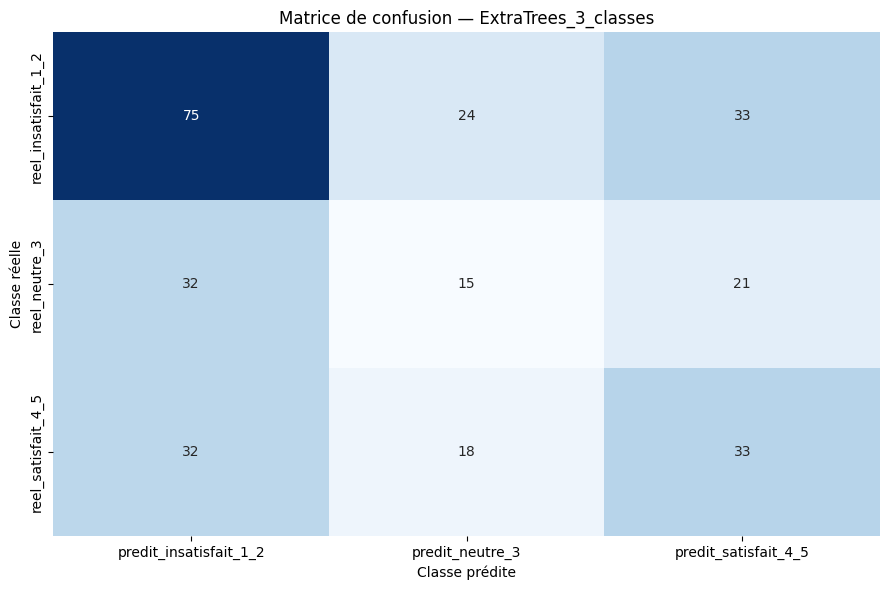

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matrice de confusion — lignes = réel, colonnes = prédit")
display(confusion_post)

plt.figure(figsize=(9, 6))
sns.heatmap(
    confusion_post,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion — {best_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

### 9.6 Rapport de classification du modèle retenu

In [16]:
display(report_post.round(4))

,precision,recall,f1-score,support
insatisfait_1_2,0.5396,0.5682,0.5535,132.0000
neutre_3,0.2632,0.2206,0.2400,68.0000
satisfait_4_5,0.3793,0.3976,0.3882,83.0000
accuracy,0.4346,0.4346,0.4346,0.4346
macro avg,0.3940,0.3955,0.3939,283.0000
weighted avg,0.4262,0.4346,0.4297,283.0000


### 9.7 Importance des variables du modèle retenu

In [17]:
if hasattr(best_post_pipeline.named_steps["model"], "feature_importances_"):
    feature_names = best_post_pipeline.named_steps["preprocess"].get_feature_names_out()
    importances = best_post_pipeline.named_steps["model"].feature_importances_

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )
    display(importance_df.round(4))
else:
    print("Le modèle retenu ne fournit pas d'importance des variables directement exploitable.")

,feature,importance
13,num__imprevu_present,0.0312
50,cat__imprevus_aucun,0.0306
4,num__respect_budget,0.0281
6,num__part_vol_budget,0.0278
17,num__gravite_imprevu,0.0274
16,num__budget_non_respecte,0.0274
0,num__budget_total,0.0274
5,num__budget_par_jour,0.0265
2,num__prix_vol,0.0264
3,num__reorganisation_necessaire,0.0262


## 10. Synthèse finale

| Axe | Conclusion |
| --- | --- |
| Pré-voyage | Modèle conforme au besoin de planification, mais performance limitée par le manque de signal disponible avant départ. |
| Post-voyage | Modèle plus pertinent en 3 classes, car les variables opérationnelles expliquent mieux la satisfaction. |
| NLP `retour_client` | Utile pour l'analyse qualitative, mais non retenu dans le modèle principal car trop proche de la satisfaction. |
| SMOTE / XGBoost / RF optimisé | Testés comme améliorations, mais non retenus si le `macro_f1` ne dépasse pas le meilleur modèle simple. |

Le modèle à préparer pour l'étape suivante est donc le meilleur modèle post-voyage 3 classes sans texte libre.

## 11. Références documentaires du projet

In [18]:
documents = pd.DataFrame([
    {
        "document": "docs/etat_projet.md",
        "role": "historique technique du projet, environnement, Docker, Git, Jupyter",
    },
    {
        "document": "docs/objectif_1_dataset.md",
        "role": "identification du dataset, besoins métiers, cas d'usage, datasheet",
    },
    {
        "document": "docs/experiences_modelisation.md",
        "role": "détail des expériences de modélisation et conclusions",
    },
    {
        "document": "notebooks/Exam.ipynb",
        "role": "notebook pré-voyage détaillé et historique",
    },
    {
        "document": "notebooks/objectif_2_post_voyage.ipynb",
        "role": "notebook post-voyage détaillé et historique",
    },
])

display(documents)

,document,role
0,docs/etat_projet.md,"historique technique du projet, environnement,..."
1,docs/objectif_1_dataset.md,"identification du dataset, besoins métiers, ca..."
2,docs/experiences_modelisation.md,détail des expériences de modélisation et conc...
3,notebooks/Exam.ipynb,notebook pré-voyage détaillé et historique
4,notebooks/objectif_2_post_voyage.ipynb,notebook post-voyage détaillé et historique
